<a href="https://colab.research.google.com/github/souhaylelhammadi/analytique-des-donn-es-et-informatique-d-cisionnelle/blob/main/Optimisation_d%E2%80%99un_R%C3%A9seau_de_Neurones_Artificiels_(ANN)_par_Momentum%2C_Sharpness_Aware_Minimization_(SAM)_et_un_Quantum_Attention_Mechanism_(QAM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu
input_dim = 64 | n_classes = 10
[SGD] Epoch 01/60 | train acc=0.2299 | val acc=0.4333 | val recall=0.4310 | val f1=0.3760
[SGD] Epoch 10/60 | train acc=0.8552 | val acc=0.8444 | val recall=0.8420 | val f1=0.8265
[SGD] Epoch 20/60 | train acc=0.9451 | val acc=0.9148 | val recall=0.9145 | val f1=0.9149
[SGD] Epoch 30/60 | train acc=0.9674 | val acc=0.9370 | val recall=0.9369 | val f1=0.9371
[SGD] Epoch 40/60 | train acc=0.9777 | val acc=0.9481 | val recall=0.9480 | val f1=0.9480
[SGD] Epoch 50/60 | train acc=0.9841 | val acc=0.9519 | val recall=0.9518 | val f1=0.9519
[SGD] Epoch 60/60 | train acc=0.9897 | val acc=0.9593 | val recall=0.9592 | val f1=0.9593
[SGD+Mom+SAM] Epoch 01/60 | train acc=0.3922 | val acc=0.7333 | val recall=0.7314 | val f1=0.7149
[SGD+Mom+SAM] Epoch 10/60 | train acc=0.9920 | val acc=0.9519 | val recall=0.9516 | val f1=0.9522
[SGD+Mom+SAM] Epoch 20/60 | train acc=0.9992 | val acc=0.9667 | val recall=0.9665 | val f1=0.9666
[SGD+Mom+SAM] Epoch 30/60 | trai

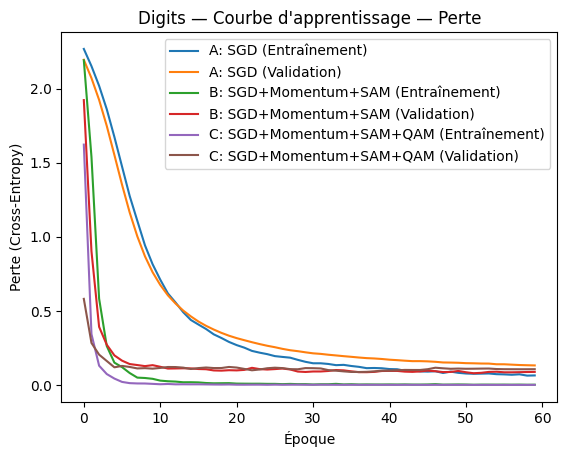

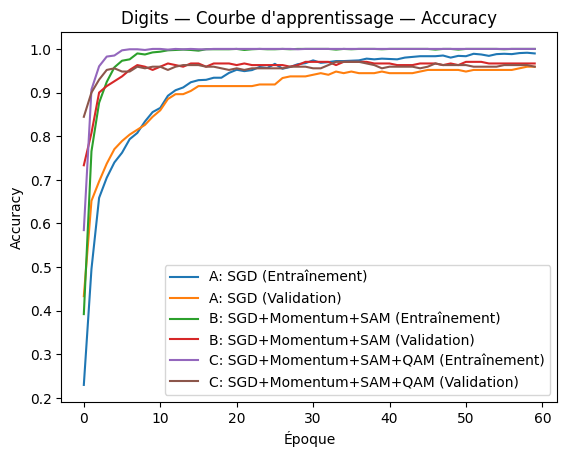

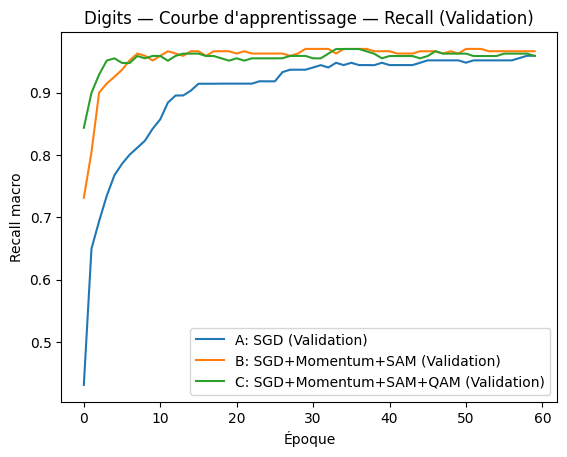

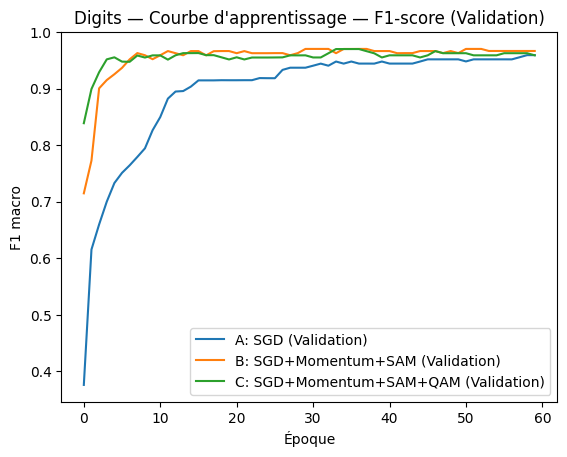


================= COMPARAISON (VALIDATION & TEST) =================
                         temps_entrainement_sec  val_accuracy  \
A: SGD                                  10.7400        0.9593   
B: SGD+Momentum+SAM                     15.4642        0.9667   
C: SGD+Momentum+SAM+QAM                 22.6619        0.9593   

                         val_precision_macro  val_recall_macro  val_f1_macro  \
A: SGD                                0.9606            0.9592        0.9593   
B: SGD+Momentum+SAM                   0.9676            0.9665        0.9667   
C: SGD+Momentum+SAM+QAM               0.9607            0.9588        0.9590   

                         test_accuracy  test_precision_macro  \
A: SGD                          0.9667                0.9681   
B: SGD+Momentum+SAM             0.9778                0.9778   
C: SGD+Momentum+SAM+QAM         0.9852                0.9860   

                         test_recall_macro  test_f1_macro  
A: SGD                          

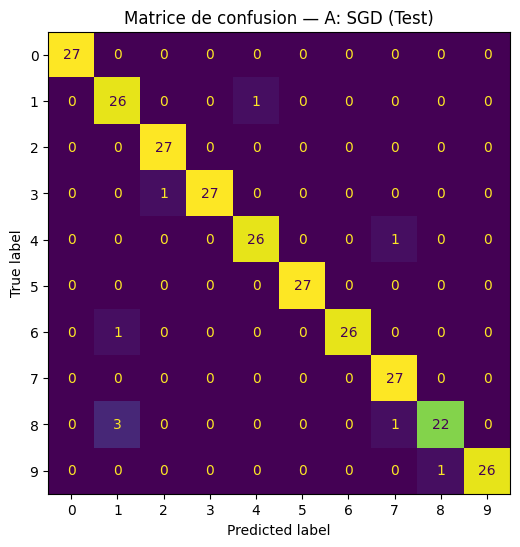

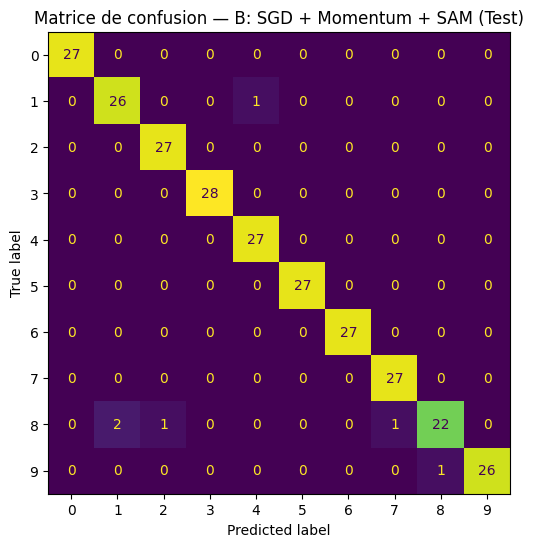

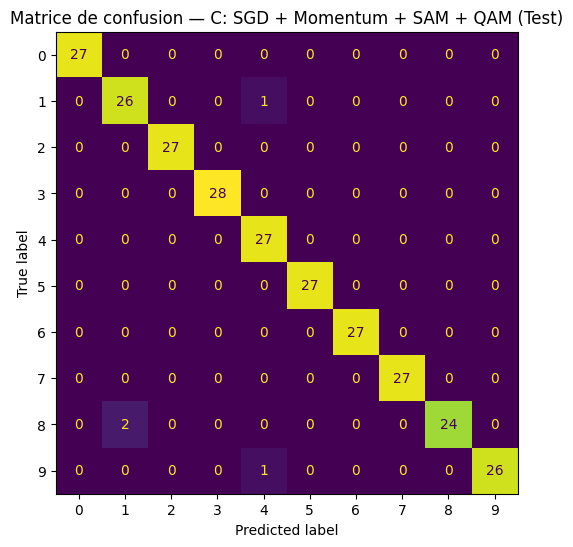

In [2]:
# ============================================================
# PROJET OPTIMISATION D’UN ANN — CODE COMPLET (AVEC AFFICHAGE COMME L'IMAGE)
#
# (A) ANN + SGD (baseline)
# (B) ANN + SGD + Momentum + SAM
# (C) ANN + SGD + Momentum + SAM + Quantum Attention Mechanism (QAM) "quantum-inspired"
#
# Dataset: Digits (sklearn) — 10 classes
#
# 2) Résultats expérimentaux :
#    - Accuracy (val + test)
#    - Recall_macro (val + test)
#    - F1_macro (val + test)
#    - Precision_macro (val + test)
#    - Learning Curves (titres en FR)
#    - Confusion Matrix (test)
#    - Temps d’entraînement
#
# Requirements: torch, numpy, matplotlib, scikit-learn
# (Optionnel) pandas (tableau comparatif plus propre)
# ============================================================

import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Tuple, List

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader


# -------------------------
# 0) Seed + device
# -------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# -------------------------
# 1) Dataset (Digits) + loaders
# -------------------------
def get_digits_loaders(test_size=0.15, val_size=0.15, batch_size=128):
    digits = load_digits()
    X = digits.data.astype(np.float32)
    y = digits.target.astype(np.int64)

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    val_relative = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_relative, random_state=42, stratify=y_trainval
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t   = torch.tensor(X_val, dtype=torch.float32)
    y_val_t   = torch.tensor(y_val, dtype=torch.long)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),     batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),   batch_size=batch_size, shuffle=False)

    input_dim = X_train.shape[1]
    n_classes = len(np.unique(y))
    return train_loader, val_loader, test_loader, input_dim, n_classes

train_loader, val_loader, test_loader, input_dim, n_classes = get_digits_loaders()
print("input_dim =", input_dim, "| n_classes =", n_classes)


# -------------------------
# 2) Metrics helpers
# -------------------------
@torch.no_grad()
def evaluate(model, loader) -> Dict[str, float]:
    model.eval()
    all_preds, all_true = [], []
    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb, reduction="sum")
        total_loss += loss.item()
        total_n += yb.numel()

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu().numpy())
        all_true.append(yb.detach().cpu().numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    avg_loss = total_loss / max(total_n, 1)

    return {"loss": avg_loss, "acc": acc, "precision_macro": prec, "recall_macro": rec, "f1_macro": f1}

@torch.no_grad()
def predict_all(model, loader) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_preds, all_true = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)


# -------------------------

# -------------------------
def log_epoch(tag: str, epoch: int, epochs: int, train_acc: float, val_m: dict, print_every: int = 10):
    if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
        print(
            f"[{tag}] Epoch {epoch:02d}/{epochs} | "
            f"train acc={train_acc:.4f} | "
            f"val acc={val_m['acc']:.4f} | "
            f"val recall={val_m['recall_macro']:.4f} | "
            f"val f1={val_m['f1_macro']:.4f}"
        )


# -------------------------
# 4) SAM (standalone)
# -------------------------
class SAM:
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False):
        self.params = list(params)
        self.base_optimizer = base_optimizer
        self.rho = rho
        self.adaptive = adaptive
        self.e_w = {}

    def zero_grad(self):
        try:
            self.base_optimizer.zero_grad(set_to_none=True)
        except TypeError:
            self.base_optimizer.zero_grad()

    @torch.no_grad()
    def _grad_norm(self):
        norms = []
        for p in self.params:
            if p.grad is None:
                continue
            if self.adaptive:
                norms.append((torch.abs(p) * p.grad).norm(p=2))
            else:
                norms.append(p.grad.norm(p=2))
        if len(norms) == 0:
            return torch.tensor(0.0, device=self.params[0].device)
        return torch.norm(torch.stack(norms), p=2)

    @torch.no_grad()
    def first_step(self, zero_grad=True):
        grad_norm = self._grad_norm()
        if grad_norm == 0:
            return
        scale = self.rho / (grad_norm + 1e-12)

        for p in self.params:
            if p.grad is None:
                continue
            ew = (torch.pow(p, 2) * p.grad if self.adaptive else p.grad) * scale
            p.add_(ew)
            self.e_w[id(p)] = ew

        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=True):
        for p in self.params:
            if p.grad is None:
                continue
            ew = self.e_w.get(id(p), None)
            if ew is not None:
                p.sub_(ew)

        self.base_optimizer.step()

        if zero_grad:
            self.zero_grad()


# -------------------------
# 5) QAM (quantum-inspired)
# -------------------------
class QuantumAttentionLayer(nn.Module):
    def __init__(self, dim: int, n_heads: int = 4, qam_dim: int = 64):
        super().__init__()
        assert dim % n_heads == 0
        self.n_heads = n_heads
        self.dk = dim // n_heads

        self.Wq = nn.Linear(dim, dim, bias=False)
        self.Wk = nn.Linear(dim, dim, bias=False)
        self.Wv = nn.Linear(dim, dim, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)

        self.qam_W = nn.Parameter(torch.randn(qam_dim, dim) * 0.2)
        self.qam_phi = nn.Parameter(torch.zeros(qam_dim))
        self.gate = nn.Linear(2 * qam_dim, dim)

        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        B, D = x.shape
        q = self.Wq(x).view(B, self.n_heads, self.dk)
        k = self.Wk(x).view(B, self.n_heads, self.dk)
        v = self.Wv(x).view(B, self.n_heads, self.dk)

        scores = torch.matmul(q, k.transpose(1, 2)) / math.sqrt(self.dk)
        attn = torch.softmax(scores, dim=-1)
        ctx = torch.matmul(attn, v).contiguous().view(B, D)
        attn_out = self.out(ctx)

        proj = F.linear(x, self.qam_W) + self.qam_phi
        qfeat = torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1)
        g = torch.sigmoid(self.gate(qfeat))

        return self.norm(x + g * attn_out)


# -------------------------
# 6) Models
# -------------------------
class ANN_Baseline(nn.Module):
    def __init__(self, input_dim, n_classes, hidden=256, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)

class ANN_With_QAM(nn.Module):
    def __init__(self, input_dim, n_classes, hidden=256, dropout=0.15, qam_dim=64, n_heads=4):
        super().__init__()
        self.fc_in = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout)
        )
        self.qam = QuantumAttentionLayer(hidden, n_heads=n_heads, qam_dim=qam_dim)
        self.fc_out = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        h = self.fc_in(x)
        h = self.qam(h)
        return self.fc_out(h)


# -------------------------
# 7) Training loops (avec logs comme image)
# -------------------------
@dataclass
class TrainConfig:
    epochs: int = 60
    lr: float = 0.05
    momentum: float = 0.0
    weight_decay: float = 0.0
    sam_rho: float = 0.05
    use_sam: bool = False
    print_every: int = 10


def train_sgd_with_logs(model, cfg: TrainConfig, train_loader, val_loader, tag="SGD") -> Tuple[Dict[str, List[float]], float]:
    model.to(device)
    opt = torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay)

    hist = {"train_loss": [], "val_loss": [],
            "train_acc": [], "val_acc": [],
            "val_precision_macro": [], "val_recall_macro": [], "val_f1_macro": []}

    t0 = time.time()

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        running_loss, total, correct = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.step()

            running_loss += loss.item() * yb.size(0)
            total += yb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total
        val_m = evaluate(model, val_loader)

        hist["train_loss"].append(train_loss)
        hist["train_acc"].append(train_acc)
        hist["val_loss"].append(val_m["loss"])
        hist["val_acc"].append(val_m["acc"])
        hist["val_precision_macro"].append(val_m["precision_macro"])
        hist["val_recall_macro"].append(val_m["recall_macro"])
        hist["val_f1_macro"].append(val_m["f1_macro"])

        log_epoch(tag, epoch, cfg.epochs, train_acc, val_m, print_every=cfg.print_every)

    return hist, time.time() - t0


def train_sam_with_logs(model, cfg: TrainConfig, train_loader, val_loader, tag="SGD+Mom+SAM") -> Tuple[Dict[str, List[float]], float]:
    model.to(device)
    base_opt = torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    opt = SAM(model.parameters(), base_opt, rho=cfg.sam_rho, adaptive=False)

    hist = {"train_loss": [], "val_loss": [],
            "train_acc": [], "val_acc": [],
            "val_precision_macro": [], "val_recall_macro": [], "val_f1_macro": []}

    t0 = time.time()

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        running_loss, total, correct = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            opt.first_step(zero_grad=True)

            logits2 = model(xb)
            loss2 = F.cross_entropy(logits2, yb)
            loss2.backward()
            opt.second_step(zero_grad=True)

            running_loss += loss.item() * yb.size(0)
            total += yb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total
        val_m = evaluate(model, val_loader)

        hist["train_loss"].append(train_loss)
        hist["train_acc"].append(train_acc)
        hist["val_loss"].append(val_m["loss"])
        hist["val_acc"].append(val_m["acc"])
        hist["val_precision_macro"].append(val_m["precision_macro"])
        hist["val_recall_macro"].append(val_m["recall_macro"])
        hist["val_f1_macro"].append(val_m["f1_macro"])

        log_epoch(tag, epoch, cfg.epochs, train_acc, val_m, print_every=cfg.print_every)

    return hist, time.time() - t0


# -------------------------
# 8) Courbes en FR + comparaison
# -------------------------
def plot_curves_fr(histories: Dict[str, Dict[str, List[float]]], prefix="Digits — "):
    # Perte
    plt.figure()
    for name, h in histories.items():
        plt.plot(h["train_loss"], label=f"{name} (Entraînement)")
        plt.plot(h["val_loss"],   label=f"{name} (Validation)")
    plt.xlabel("Époque")
    plt.ylabel("Perte (Cross-Entropy)")
    plt.title(prefix + "Courbe d'apprentissage — Perte")
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    for name, h in histories.items():
        plt.plot(h["train_acc"], label=f"{name} (Entraînement)")
        plt.plot(h["val_acc"],   label=f"{name} (Validation)")
    plt.xlabel("Époque")
    plt.ylabel("Accuracy")
    plt.title(prefix + "Courbe d'apprentissage — Accuracy")
    plt.legend()
    plt.show()

    # Recall macro (validation)
    plt.figure()
    for name, h in histories.items():
        plt.plot(h["val_recall_macro"], label=f"{name} (Validation)")
    plt.xlabel("Époque")
    plt.ylabel("Recall macro")
    plt.title(prefix + "Courbe d'apprentissage — Recall (Validation)")
    plt.legend()
    plt.show()

    # F1 macro (validation)
    plt.figure()
    for name, h in histories.items():
        plt.plot(h["val_f1_macro"], label=f"{name} (Validation)")
    plt.xlabel("Époque")
    plt.ylabel("F1 macro")
    plt.title(prefix + "Courbe d'apprentissage — F1-score (Validation)")
    plt.legend()
    plt.show()


def show_confusion_fr(model, loader, title):
    y_true, y_pred = predict_all(model, loader)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
    plt.show()


# ============================================================
# 9) RUN EXPÉRIENCES (avec logs comme l'image)
# ============================================================

# A) SGD
cfg_A = TrainConfig(epochs=60, lr=0.05, momentum=0.0, use_sam=False, print_every=10)
model_A = ANN_Baseline(input_dim, n_classes)
hist_A, time_A = train_sgd_with_logs(model_A, cfg_A, train_loader, val_loader, tag="SGD")

# B) SGD + Momentum + SAM
cfg_B = TrainConfig(epochs=60, lr=0.05, momentum=0.9, sam_rho=0.05, use_sam=True, print_every=10)
model_B = ANN_Baseline(input_dim, n_classes)
hist_B, time_B = train_sam_with_logs(model_B, cfg_B, train_loader, val_loader, tag="SGD+Mom+SAM")

# C) SGD + Momentum + SAM + QAM
cfg_C = TrainConfig(epochs=60, lr=0.05, momentum=0.9, sam_rho=0.05, use_sam=True, print_every=10)
model_C = ANN_With_QAM(input_dim, n_classes)
hist_C, time_C = train_sam_with_logs(model_C, cfg_C, train_loader, val_loader, tag="SGD+Mom+SAM+QAM")


# ============================================================
# 10) Learning curves (titres FR)
# ============================================================
histories = {
    "A: SGD": hist_A,
    "B: SGD+Momentum+SAM": hist_B,
    "C: SGD+Momentum+SAM+QAM": hist_C,
}
plot_curves_fr(histories, prefix="Digits — ")


# ============================================================
# 11) Évaluation finale + comparaison (VAL & TEST)
# ============================================================
val_A = evaluate(model_A, val_loader); test_A = evaluate(model_A, test_loader)
val_B = evaluate(model_B, val_loader); test_B = evaluate(model_B, test_loader)
val_C = evaluate(model_C, val_loader); test_C = evaluate(model_C, test_loader)

results = {
    "A: SGD": {
        "temps_entrainement_sec": time_A,
        "val_accuracy": val_A["acc"],
        "val_precision_macro": val_A["precision_macro"],
        "val_recall_macro": val_A["recall_macro"],
        "val_f1_macro": val_A["f1_macro"],
        "test_accuracy": test_A["acc"],
        "test_precision_macro": test_A["precision_macro"],
        "test_recall_macro": test_A["recall_macro"],
        "test_f1_macro": test_A["f1_macro"],
    },
    "B: SGD+Momentum+SAM": {
        "temps_entrainement_sec": time_B,
        "val_accuracy": val_B["acc"],
        "val_precision_macro": val_B["precision_macro"],
        "val_recall_macro": val_B["recall_macro"],
        "val_f1_macro": val_B["f1_macro"],
        "test_accuracy": test_B["acc"],
        "test_precision_macro": test_B["precision_macro"],
        "test_recall_macro": test_B["recall_macro"],
        "test_f1_macro": test_B["f1_macro"],
    },
    "C: SGD+Momentum+SAM+QAM": {
        "temps_entrainement_sec": time_C,
        "val_accuracy": val_C["acc"],
        "val_precision_macro": val_C["precision_macro"],
        "val_recall_macro": val_C["recall_macro"],
        "val_f1_macro": val_C["f1_macro"],
        "test_accuracy": test_C["acc"],
        "test_precision_macro": test_C["precision_macro"],
        "test_recall_macro": test_C["recall_macro"],
        "test_f1_macro": test_C["f1_macro"],
    },
}

print("\n================= COMPARAISON (VALIDATION & TEST) =================")
try:
    import pandas as pd
    df = pd.DataFrame(results).T
    cols = [
        "temps_entrainement_sec",
        "val_accuracy","val_precision_macro","val_recall_macro","val_f1_macro",
        "test_accuracy","test_precision_macro","test_recall_macro","test_f1_macro",
    ]
    print(df[cols].round(4))
except Exception:
    for k, v in results.items():
        print(k, "=>", {kk: round(vv, 4) if isinstance(vv, float) else vv for kk, vv in v.items()})


# ============================================================
# 12) Reports (TEST) + Matrices de confusion (FR)
# ============================================================
y_true_A, y_pred_A = predict_all(model_A, test_loader)
y_true_B, y_pred_B = predict_all(model_B, test_loader)
y_true_C, y_pred_C = predict_all(model_C, test_loader)

print("\n================= RAPPORT DE CLASSIFICATION (TEST) =================")
print("\n--- A: SGD ---")
print(classification_report(y_true_A, y_pred_A, zero_division=0))
print("\n--- B: SGD+Momentum+SAM ---")
print(classification_report(y_true_B, y_pred_B, zero_division=0))
print("\n--- C: SGD+Momentum+SAM+QAM ---")
print(classification_report(y_true_C, y_pred_C, zero_division=0))

show_confusion_fr(model_A, test_loader, "Matrice de confusion — A: SGD (Test)")
show_confusion_fr(model_B, test_loader, "Matrice de confusion — B: SGD + Momentum + SAM (Test)")
show_confusion_fr(model_C, test_loader, "Matrice de confusion — C: SGD + Momentum + SAM + QAM (Test)")